In [1]:
import sys
import importlib

import numpy as np
import pandas as pd
import os.path

# Import the model we are using
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
import sys
sys.path.append('.') # Adds the current directory
import BTSSlayers as btss 

In [3]:
# set dataframe vizualisation options 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [6]:
# Read a large set of 491 translation sessions from the TPR-DB
GD = pd.read_csv('sorted.gaze.clean.txt', sep="\t", dtype=None)

# read the Tables from the TPR-DB
BTSS1 = btss.readBTSSsessions(GD['Study-Session'], layers = ['au1', 'fd','kd'], verbose=0)

# rename for easier use
AUdf_old = BTSS1['au1']
FDdf = BTSS1['fd'] 
KDdf_old = BTSS1['kd']
print("AUs:", AUdf_old.shape, "FDs:", FDdf.shape, "KDs:", KDdf_old.shape)

AUs: (263719, 73) FDs: (999492, 22) KDs: (564649, 25)


In [7]:
FDdf['StudySession'] = FDdf['Study'] + '-' + FDdf['Session']
#FDdf = FDdf.drop_duplicates(subset = ['StudySession'])
FDdf.shape

(999492, 23)

In [8]:
FDdf_session = FDdf.drop_duplicates(subset = ['StudySession'])
FDdf_session.shape

(490, 23)

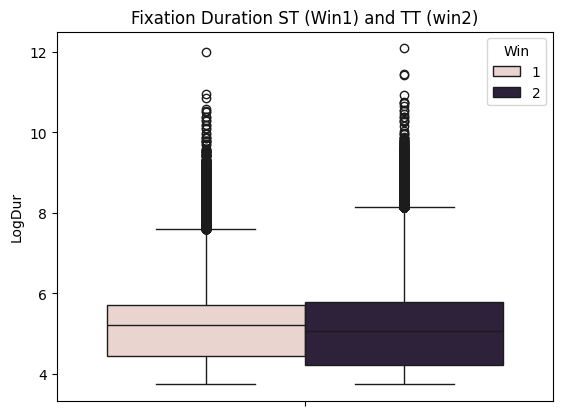

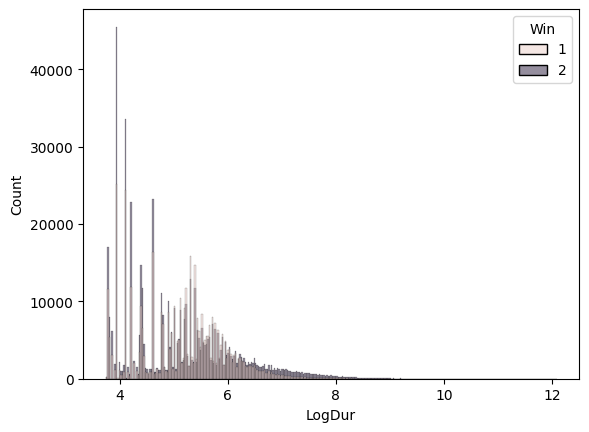

In [9]:
# Log duration of fixation
FDdf['LogDur'] = np.log1p(FDdf.Dur)

sns.boxplot(data=FDdf, y="LogDur", hue='Win').set(title='Fixation Duration ST (Win1) and TT (win2)')
plt.show()

sns.histplot(data=FDdf, x="LogDur", hue='Win')
plt.show()



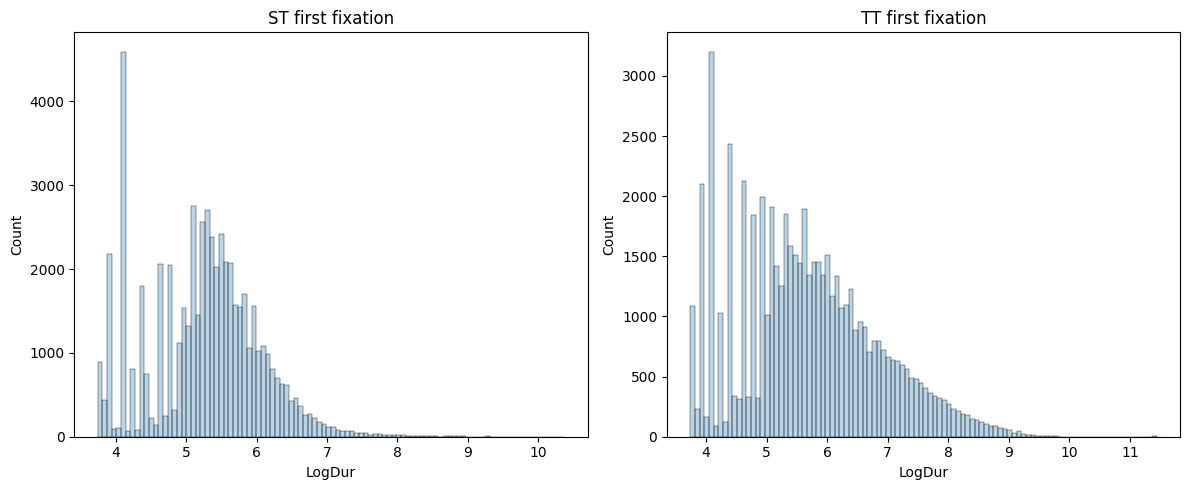

In [10]:
# Log duration of first fixation on ST and TT words
FDdf['StudySessionWinFirst'] = FDdf['StudySession'] + '-' + FDdf['Win'].astype(str)  + '.' + FDdf['SGid'].astype(str) 

FDst = FDdf[FDdf.Win == 1].copy()
FDtt = FDdf[FDdf.Win == 2].copy()

FDst['StudySessionFirst'] = FDst['StudySession'] + FDst['SGid'].astype(str)
FDtt['StudySessionFirst'] = FDtt['StudySession'] + FDtt['TGid'].astype(str)

FDst_first = FDst.drop_duplicates(subset=['StudySessionFirst'], keep='first')
FDtt_first = FDtt.drop_duplicates(subset=['StudySessionFirst'], keep='first')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=FDst_first, x='LogDur', alpha=0.3, bins=100, ax=ax1)
ax1.set_title('ST first fixation')

sns.histplot(data=FDtt_first, x='LogDur', alpha=0.3, bins=100, ax=ax2)
ax2.set_title('TT first fixation')

fig.tight_layout()
plt.show()

##  All sessions - Finding Thresholds for Automatic and Conscious processing

## Mean and Standard Deviation

In [11]:
# Calculating mean and standard deviation for ST and TT Data 
mean_st = FDst_first['LogDur'].mean()
std_st = FDst_first['LogDur'].std()

mean_tt = FDtt_first['LogDur'].mean()
std_tt = FDtt_first['LogDur'].std()

print(f"ST Data: Mean = {mean_st:.2f}, Std Dev = {std_st:.2f}")
print(f"TT Data: Mean = {mean_tt:.2f}, Std Dev = {std_tt:.2f}")

ST Data: Mean = 5.25, Std Dev = 0.79
TT Data: Mean = 5.66, Std Dev = 1.16
